In [29]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [30]:
# ==========================================
# 1. DOWNLOAD & LOAD DATA
# ==========================================
url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"

if not os.path.exists("LD2011_2014.txt"):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, "data.zip")
    with zipfile.ZipFile("data.zip", "r") as zip_ref:
        zip_ref.extractall()

print("Loading CSV...")
df = pd.read_csv("LD2011_2014.txt", sep=";", decimal=",", skiprows=1, header=None)

# Set datetime index
df["Timestamp"] = pd.to_datetime(df[0])
df = df.drop(columns=[0]).set_index("Timestamp")

# Convert strings to floats
df = df.apply(pd.to_numeric, errors="coerce")

# Aggregate across all customers and convert to daily MWh
total_kw = df.sum(axis=1)
daily_mwh = total_kw.resample("D").sum() * 0.25 / 1000

# Filter for full years 2012-2014
daily = daily_mwh.loc["2012":"2014"].dropna()
daily.name = "Load_MWh"

print(f"Data shape after cleaning: {daily.shape}")

Loading CSV...
Data shape after cleaning: (1096,)


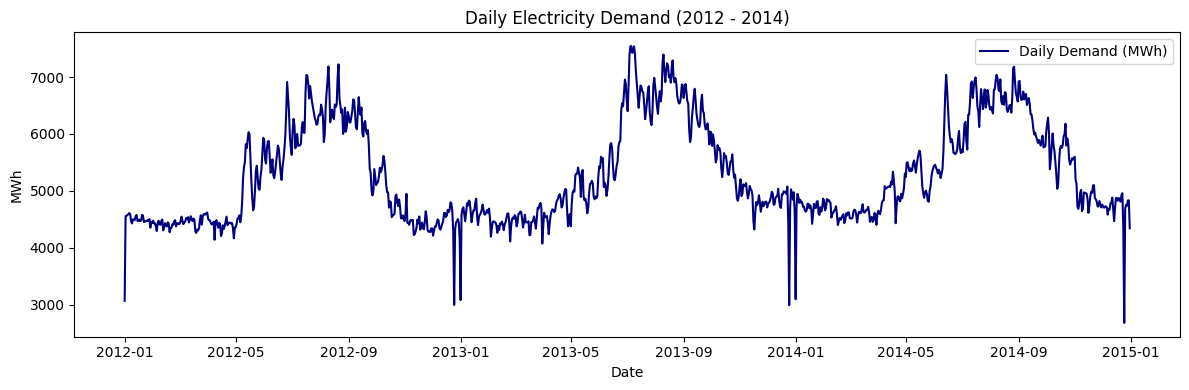

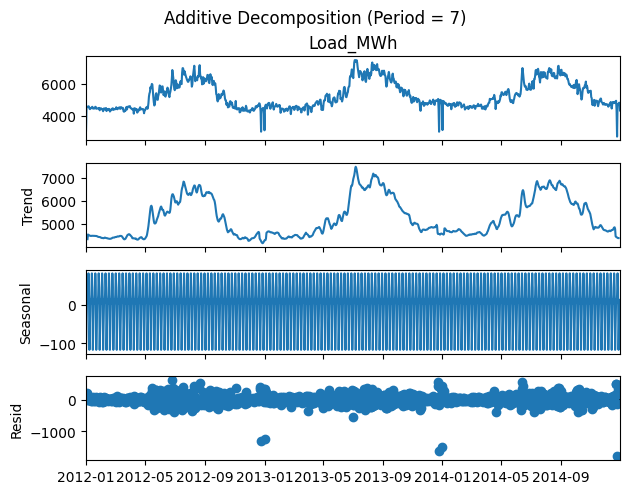

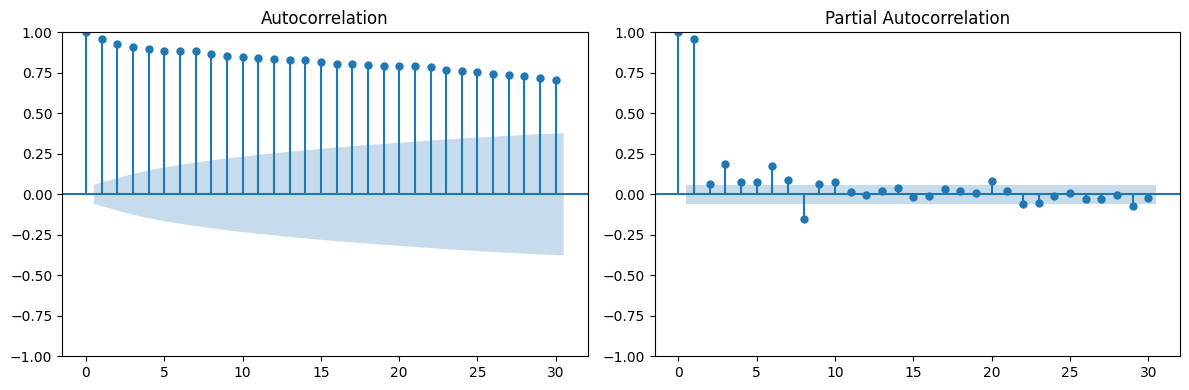


--- Stationarity Test Results ---
ADF Statistic: -1.8519, p-value: 0.3550
KPSS Statistic: 0.4440, p-value: 0.0582


In [31]:
# ==========================================
# 2. EDA & DECOMPOSITION
# ==========================================
# Plot full series
plt.figure(figsize=(12, 4))
plt.plot(daily, color="navy", label="Daily Demand (MWh)")
plt.title("Daily Electricity Demand (2012 - 2014)")
plt.xlabel("Date")
plt.ylabel("MWh")
plt.legend()
plt.tight_layout()
plt.show()

# Seasonal decomposition (weekly cycle = 7 days)
decomp = seasonal_decompose(daily, model="additive", period=7)
decomp.plot()
plt.suptitle("Additive Decomposition (Period = 7)", y=1.02)
plt.show()

# ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(daily, lags=30, ax=axes[0], title="Autocorrelation")
plot_pacf(daily, lags=30, ax=axes[1], title="Partial Autocorrelation")
plt.tight_layout()
plt.show()

# Stationarity Tests
adf_res = adfuller(daily)
kpss_res = kpss(daily, regression="c", nlags="auto")

print("\n--- Stationarity Test Results ---")
print(f"ADF Statistic: {adf_res[0]:.4f}, p-value: {adf_res[1]:.4f}")
print(f"KPSS Statistic: {kpss_res[0]:.4f}, p-value: {kpss_res[1]:.4f}")


In [32]:
# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================
horizon = 30
train = daily.iloc[:-horizon]
test = daily.iloc[-horizon:]

print(f"\nTrain size: {len(train)} days | Test size: {len(test)} days")



Train size: 1066 days | Test size: 30 days


In [33]:
# ==========================================
# 4. MODEL TRAINING
# ==========================================

# --- Baseline: Seasonal Naive (Repeat last week) ---
s_naive_pred = pd.Series(
    np.tile(train.iloc[-7:].values, int(np.ceil(horizon / 7)))[:horizon],
    index=test.index
)

# --- Model 1: Standard ARIMA ---
print("\nFitting Non-Seasonal ARIMA...")
arima_model = auto_arima(train, seasonal=False, suppress_warnings=True)
arima_pred = pd.Series(arima_model.predict(n_periods=horizon), index=test.index)

# --- Model 2: SARIMA ---
print("Fitting SARIMA (m=7)...")
sarima_model = auto_arima(train, seasonal=True, m=7, suppress_warnings=True)
sarima_pred = pd.Series(sarima_model.predict(n_periods=horizon), index=test.index)

# --- Model 3: XGBoost with Lag Features ---
print("Fitting XGBoost...")
df_xgb = pd.DataFrame({"y": daily})

# Feature engineering
df_xgb["dow"] = df_xgb.index.dayofweek
df_xgb["month"] = df_xgb.index.month
df_xgb["lag1"] = df_xgb["y"].shift(1)
df_xgb["lag7"] = df_xgb["y"].shift(7)
df_xgb["lag14"] = df_xgb["y"].shift(14)
df_xgb["roll7"] = df_xgb["y"].shift(1).rolling(7).mean()

df_xgb = df_xgb.dropna()

features = ["dow", "month", "lag1", "lag7", "lag14", "roll7"]
X = df_xgb[features]
y = df_xgb["y"]

# Train mask (only up to train set split)
train_mask = X.index < test.index[0]
X_train, y_train = X[train_mask], y[train_mask]

xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.03, random_state=42)
xgb.fit(X_train, y_train)

# Multi-step rolling prediction loop
hist = list(train.values)
xgb_predictions = []

for step_date in test.index:
    curr_dow = step_date.dayofweek
    curr_month = step_date.month

    # Take lags from rolling history
    l1 = hist[-1]
    l7 = hist[-7]
    l14 = hist[-14]
    r7 = np.mean(hist[-7:])

    feat_vector = pd.DataFrame([[curr_dow, curr_month, l1, l7, l14, r7]], columns=features)
    pred_val = xgb.predict(feat_vector)[0]

    xgb_predictions.append(pred_val)
    hist.append(pred_val) # append forecast to history for next step

xgb_pred = pd.Series(xgb_predictions, index=test.index)



Fitting Non-Seasonal ARIMA...
Fitting SARIMA (m=7)...
Fitting XGBoost...



--- Final Model Comparison ---
            Model     MAE    RMSE  MAPE (%)
0  Seasonal Naive  170.30  399.22      4.75
1         XGBoost  190.11  405.25      5.14
2           ARIMA  179.20  408.82      4.97
3          SARIMA  174.68  417.92      4.91


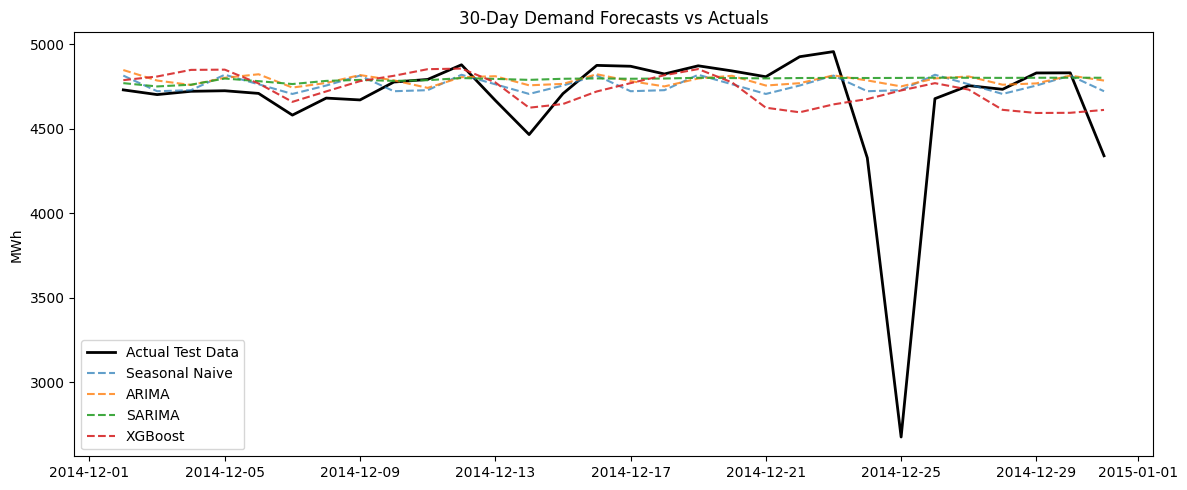

In [34]:
# ==========================================
# 5. EVALUATION
# ==========================================
def get_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

all_models = {
    "Seasonal Naive": s_naive_pred,
    "ARIMA": arima_pred,
    "SARIMA": sarima_pred,
    "XGBoost": xgb_pred
}

metrics_list = []
for name, preds in all_models.items():
    m_mae, m_rmse, m_mape = get_metrics(test, preds)
    metrics_list.append({
        "Model": name,
        "MAE": round(m_mae, 2),
        "RMSE": round(m_rmse, 2),
        "MAPE (%)": round(m_mape, 2)
    })

eval_df = pd.DataFrame(metrics_list).sort_values("RMSE").reset_index(drop=True)
print("\n--- Final Model Comparison ---")
print(eval_df)

# Plot Forecasts
plt.figure(figsize=(12, 5))
plt.plot(test, label="Actual Test Data", color="black", linewidth=2)
plt.plot(s_naive_pred, "--", label="Seasonal Naive", alpha=0.7)
plt.plot(arima_pred, "--", label="ARIMA", alpha=0.8)
plt.plot(sarima_pred, "--", label="SARIMA", alpha=0.9)
plt.plot(xgb_pred, "--", label="XGBoost", alpha=0.9)
plt.title("30-Day Demand Forecasts vs Actuals")
plt.ylabel("MWh")
plt.legend()
plt.tight_layout()
plt.show()



Detected 10 potential anomaly points.


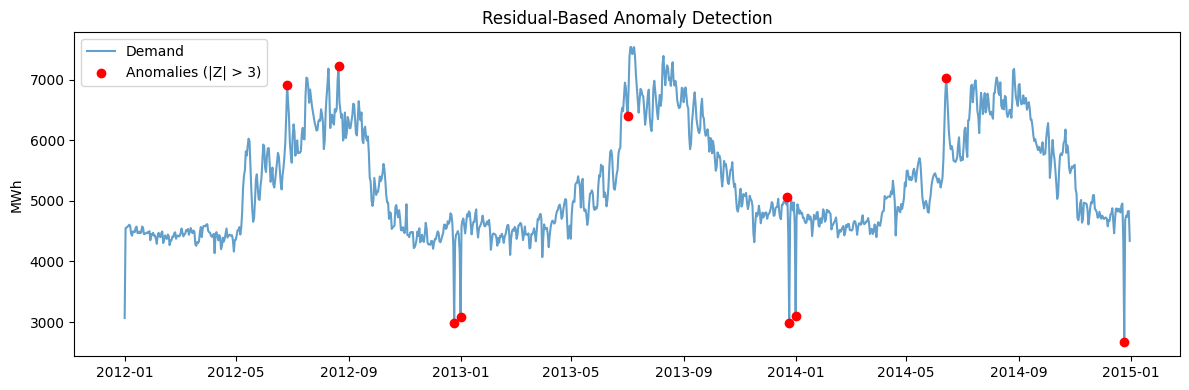

In [35]:
# ==========================================
# 6. ANOMALY DETECTION (Residual Based)
# ==========================================
residuals = decomp.resid.dropna()
z_scores = (residuals - residuals.mean()) / residuals.std()

# Filter by threshold |Z| > 3
anomalies_idx = z_scores.index[z_scores.abs() > 3]
anomalies = daily.loc[anomalies_idx]

print(f"\nDetected {len(anomalies)} potential anomaly points.")

plt.figure(figsize=(12, 4))
plt.plot(daily, label="Demand", color="tab:blue", alpha=0.7)
plt.scatter(anomalies.index, anomalies, color="red", label="Anomalies (|Z| > 3)", zorder=5)
plt.title("Residual-Based Anomaly Detection")
plt.ylabel("MWh")
plt.legend()
plt.tight_layout()
plt.show()